In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [7]:
df = pd.read_csv('./corr/모든_상관계수_결측치_제거.csv')
df

,Variable,Correlation
0,이용금액_R3M_신용체크,-6.228267e-01
1,청구금액_R6M,-5.979035e-01
2,청구금액_R3M,-5.906781e-01
3,이용금액_R3M_신용,-5.890316e-01
4,청구금액_B0,-5.779884e-01
...,...,...
710,컨택건수_이용유도_인터넷_B0M,2.260987e-03
711,컨택건수_CA_청구서_B0M,1.259665e-03
712,컨택건수_보험_TM_B0M,-9.574610e-04
713,컨택건수_CA_TM_R6M,-3.480850e-04


In [ ]:
df

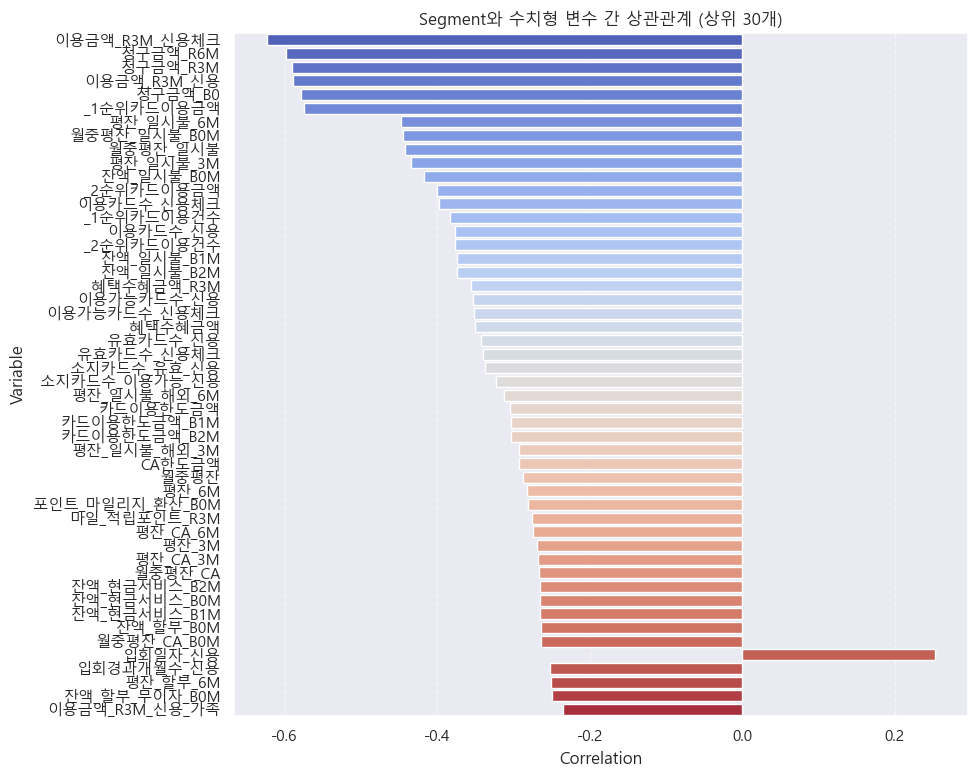

In [10]:
# 상위 20개
top_corr_df = df.head(50).reset_index(drop=True)
top_corr_df.columns = ["Variable", "Correlation"]

plt.figure(figsize=(10, 8))
sns.barplot(x="Correlation", y="Variable", data=top_corr_df, palette="coolwarm")
plt.title("Segment와 수치형 변수 간 상관관계 (상위 30개)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
filtered_df = df[df["Correlation"].abs() >= 0.7]
filtered_df

,Variable,Correlation


- 상관계수가 높은 컬럼들 중 다중공선성이 있을 것으로 예상되는 컬럼들이 존재
- 컬럼을 선정하였다면 다중공선성 (VIF)를 봐야한다.  
- 교차검증을 먼저 돌려보아라.  
- 결과 데이터랑 비교해서 그래프 그려보기. (원래는 이게 먼저이다.)

In [27]:
filtered_df = df[df["Correlation"].abs() >= 0.6]
filtered_df

,Variable,Correlation
0,이용금액_R3M_신용체크,-0.622827
213,정상청구원금_B5M,-0.660738
214,정상청구원금_B0M,-0.634571
215,정상청구원금_B2M,-0.628078


In [ ]:
filtered_df = df[df["Correlation"].abs() >= 0.5]
filtered_df

,Variable,Correlation
0,이용금액_R3M_신용체크,-0.622827
1,청구금액_R6M,-0.597904
2,청구금액_R3M,-0.590678
3,이용금액_R3M_신용,-0.589032
4,청구금액_B0,-0.577988
5,_1순위카드이용금액,-0.573870
213,정상청구원금_B5M,-0.660738
214,정상청구원금_B0M,-0.634571
215,정상청구원금_B2M,-0.628078
216,이용금액_일시불_R12M,-0.595858


In [19]:
filtered_df = df[df["Correlation"].abs() >= 0.4]
filtered_df

,Variable,Correlation
0,이용금액_R3M_신용체크,-0.622827
1,청구금액_R6M,-0.597904
2,청구금액_R3M,-0.590678
3,이용금액_R3M_신용,-0.589032
4,청구금액_B0,-0.577988
5,_1순위카드이용금액,-0.573870
6,평잔_일시불_6M,-0.447967
7,월중평잔_일시불_B0M,-0.444621
8,월중평잔_일시불,-0.441527
9,평잔_일시불_3M,-0.434514


In [20]:
filtered_df = df[df["Correlation"].abs() >= 0.35]
filtered_df

,Variable,Correlation
0,이용금액_R3M_신용체크,-0.622827
1,청구금액_R6M,-0.597904
2,청구금액_R3M,-0.590678
3,이용금액_R3M_신용,-0.589032
4,청구금액_B0,-0.577988
...,...,...
266,이용금액_온라인_R3M,-0.354728
267,이용금액_할부_R12M,-0.353568
268,쇼핑_온라인_이용금액,-0.353185
269,이용금액_온라인_R6M,-0.351423


In [25]:
filtered_df = df[df["Correlation"].abs() >= 0.3]
filtered_df

,Variable,Correlation
0,이용금액_R3M_신용체크,-0.622827
1,청구금액_R6M,-0.597904
2,청구금액_R3M,-0.590678
3,이용금액_R3M_신용,-0.589032
4,청구금액_B0,-0.577988
...,...,...
287,이용개월수_온라인_R6M,-0.321242
288,이용개월수_페이_온라인_R6M,-0.318474
289,납부_기타이용금액,-0.314270
290,이용개월수_간편결제_R6M,-0.313498


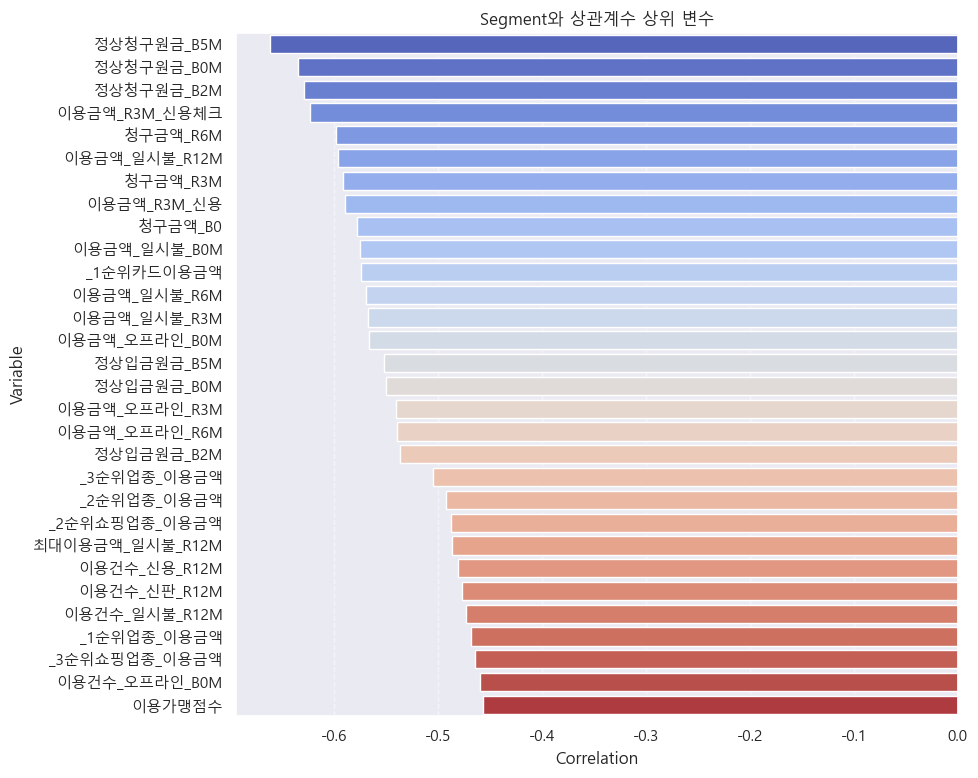

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

top_n = 30
top_corr = df.sort_values(by="Correlation", key=lambda x: abs(x), ascending=False).head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_corr, y="Variable", x="Correlation", palette="coolwarm")
plt.title("Segment와 상관계수 상위 변수")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [29]:
df1 = pd.read_parquet('./data/train/1_회원정보_train.parquet')
df1

,기준년월,ID,남녀구분코드,연령,Segment,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,...,할인금액_제휴연회비_B0M,청구금액_기본연회비_B0M,청구금액_제휴연회비_B0M,상품관련면제카드수_B0M,임직원면제카드수_B0M,우수회원면제카드수_B0M,기타면제카드수_B0M,카드신청건수,Life_Stage,최종카드발급경과월
0,201807,TRAIN_000000,2,40대,D,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),22
1,201807,TRAIN_000001,1,30대,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),18
2,201807,TRAIN_000002,1,30대,C,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,20
3,201807,TRAIN_000003,2,40대,D,1,1,0,1,2,...,0,0,0,0개,0개,0개,0개,1,자녀성장(2),17
4,201807,TRAIN_000004,2,40대,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,1,자녀성장(1),15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,2,70대이상,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,노년생활,39
2399996,201812,TRAIN_399996,2,50대,D,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),24
2399997,201812,TRAIN_399997,1,30대,C,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,18
2399998,201812,TRAIN_399998,1,40대,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),27


In [32]:
df1[["이용금액_R3M_신용체크", "이용금액_R3M_신용", "이용금액_R3M_체크"]]

,이용금액_R3M_신용체크,이용금액_R3M_신용,이용금액_R3M_체크
0,196,196,0
1,13475,13475,0
2,23988,23988,0
3,3904,3904,0
4,1190,0,1190
...,...,...,...
2399995,10755,7267,3488
2399996,27636,27636,0
2399997,23187,23187,0
2399998,0,0,0


`이용금액_R3M_신용체크`는 `이용금액_R3M_신용`과 `이용금액_R3M_체크`를 합산한 값이다.

#### 다중공선성 확인하기

In [33]:
filtered_df = df[df["Correlation"].abs() >= 0.4]
filtered_df

,Variable,Correlation
0,이용금액_R3M_신용체크,-0.622827
1,청구금액_R6M,-0.597904
2,청구금액_R3M,-0.590678
3,이용금액_R3M_신용,-0.589032
4,청구금액_B0,-0.577988
5,_1순위카드이용금액,-0.573870
6,평잔_일시불_6M,-0.447967
7,월중평잔_일시불_B0M,-0.444621
8,월중평잔_일시불,-0.441527
9,평잔_일시불_3M,-0.434514
